# Getting started with resource estimation

## High-level overview

The quantum resource estimator takes two inputs: an **application model** that describes the quantum computation (e.g., a Q# program), and an **architecture model** that describes the target quantum hardware (e.g., gate-based superconducting qubits with specific gate times and error rates). From the application, it generates one or more *traces*, compact representations of the instruction sequences applied to qubits. From the architecture, it derives a physical *instruction set* (ISA) specifying each gate's time, qubit cost, and error rate. Between these two layers sit configurable *transforms*: trace transforms such as gate decomposition and layout routines reshape the application trace, while ISA transforms such as quantum error correction codes and magic state factories build higher-fidelity logical instruction sets from the architecture's physical primitives.

<img src="overview.svg" title="Resource estimator overview" style="max-width: 1000px; width: 100%" />

Because there are many valid choices at each layer (rooted in different QEC code distances, different factory protocols, different decomposition parameters), the estimator faces a large combinatorial design space. Rather than evaluating a single fixed configuration, it systematically explores the product of all trace and ISA variants, evaluates physical qubit counts, runtimes, and accumulated error rates for each combination, and then filters the results down to a **Pareto-optimal frontier**: the set of configurations where no other result is simultaneously better in both qubits and runtime while staying within a user-specified error budget.

In practice, a typical estimation call composes these pieces in a single line, like `estimate(app, arch, isa_query=SurfaceCode.q() * RoundBasedFactory.q(), max_error=0.01)`, and returns an `EstimationTable` of Pareto-optimal results that can be inspected, extended with custom columns, or plotted. The remainder of this notebook walks through each step: setting up an application from Q#, choosing an architecture, running the estimation, and interpreting the results.

In [1]:
# Imports
from pathlib import Path

import qdk
from qdk import qsharp
from qdk.qre import estimate, property_name, plot_estimates
from qdk.qre.models import GateBased, SurfaceCode, RoundBasedFactory
from qdk.qre.application import QSharpApplication

from qdk.qre.instruction_ids import T, LATTICE_SURGERY
from qdk.qre.property_keys import NUM_TS_PER_ROTATION

## Setting up an application

In this example, we use `QSharpApplication` to define the application we want to
estimate using a Q# entry point.  Other application loaders are available to
[read quantum programs from other langauges and frameworks](1_qre_input.ipynb).
First, we load an existing Q# program from the samples directory and evaluate
it.  Alternatively, we could load a Q# project or evaluate the Q# program inline
in a notebook cell.  We create the application instance using the `Main()` entry
point of the Q# program.

In [2]:
# Evaluate the Q# application into the scope
qsharp.eval(Path("../algorithms/Ising/Simple1dIsingOrder1.qs").read_text())

# The entry point in the Q# code above is called Main
app = QSharpApplication(qdk.code.Main)

We will soon use this application instance with the `estimate` method.  This
will enumerate all possible traces given the application parameters and the
trace transform.  But just to see some information of a trace, we can get the
first trace that is enumerated from the application and look at its required ISA
to implement it.

In [3]:
# Get one of the generated traces (in fact, this application only generates one trace, but in general there could be multiple)
trace = next(app.enumerate_traces())

trace.required_isa.as_frame()

,encoding,arity
id,,
RZ,LOGICAL,1
MEAS_Z,LOGICAL,1


The output shows the logical instructions required by this trace. In this case, the algorithm needs `RZ` (arbitrary Z-rotation) and `MEAS_Z` (measurement in the Z basis), both operating on single qubits at the logical level. The resource estimator's job is to determine how many physical qubits and how much time are needed to implement these logical operations, given the target architecture and the chosen error correction scheme.

Note that the `QSharpApplication` only computes logical counts required for Pauli-based computation (PSSPC).

## Choosing a target architecture

The architecture model describes the physical quantum hardware. `GateBased` defines a gate-based architecture with configurable gate and measurement times (in nanoseconds) and a physical error rate (which defaults to $10^{-4}$). Calling `provided_isa()` on the architecture returns its physical instruction set: the set of native gates the hardware supports, along with each gate's encoding, arity, qubit cost, time, and error rate.

In [4]:
# Define a gate-based architecture: physical error rate 1e-4, gate time 100 ns, measurement 500 ns
arch = GateBased(error_rate=1e-4, gate_time=100, measurement_time=500)
arch.provided_isa(arch.context()).as_frame()

,encoding,arity,space,time,error
id,,,,,
PAULI_I,PHYSICAL,1,1,100,0.0001
SQRT_SQRT_X,PHYSICAL,1,1,100,0.0001
SQRT_SQRT_Y_DAG,PHYSICAL,1,1,100,0.0001
S,PHYSICAL,1,1,100,0.0001
SQRT_X_DAG,PHYSICAL,1,1,100,0.0001
MEAS_X,PHYSICAL,1,1,500,0.0001
RZ,PHYSICAL,1,1,100,0.0001
T_DAG,PHYSICAL,1,1,100,0.0001
PAULI_Y,PHYSICAL,1,1,100,0.0001


The table above shows the physical gates provided by this architecture. All gates operate at the `PHYSICAL` encoding level. Single-qubit gates (e.g., `H`, `T`) each use 1 physical qubit and take 100 ns, while two-qubit gates (e.g., `CNOT`, `CZ`) use 2 qubits and also take 100 ns. Measurement (`MEAS_Z`) is slower at 500 ns. All gates share the same physical error rate of $10^{-4}$.

## Estimate

The `estimate` function takes the application and architecture as inputs, along with an ISA query that specifies which quantum error correction codes and magic state factories to explore. The `SurfaceCode.q() * RoundBasedFactory.q()` ISA query enumerates the Cartesian product of surface code configurations (varying code distances) and round-based magic state distillation factories (varying distillation protocols). The `max_error` parameter sets the maximum tolerable error probability for the overall computation.

The function returns an `EstimationTable` containing only Pareto-optimal results. These are configurations where no other result is simultaneously better in both physical qubits and runtime while staying within the error budget. The default columns show the total physical qubit count, the total runtime, and the accumulated error for each result.

In [ ]:
# Run estimation over surface code × round-based factory configurations with 1% error budget
results = estimate(app, arch, isa_query=SurfaceCode.q() * RoundBasedFactory.q(), max_error=0.01)

# Returns a pandas DataFrame that can be used for further analysis or visualization
results.as_frame()

,qubits,runtime,error
0,29036,0 days 00:00:00.005213,0.003162
1,30268,0 days 00:00:00.004411,0.003162
2,32928,0 days 00:00:00.003609,0.003162
3,37996,0 days 00:00:00.002807,0.003166
4,52332,0 days 00:00:00.002005,0.003499


Each row in the table represents a Pareto-optimal configuration. The first row uses the fewest physical qubits but has the longest runtime, while the last row is the fastest but requires the most qubits. All results stay within the specified `max_error=0.01` error budget.

We can inspect the estimation statistics to see how large the design space was and how many configurations were explored to produce these Pareto-optimal results.

In [6]:
results.stats

EstimationTableStats(num_traces=32, num_isas=1248, total_jobs=17424, successful_estimates=353, pareto_results=5)

### Adding pre-configured columns to the table

The `EstimationTable` provides convenience methods to add commonly used columns. The method `add_qubit_partition_column()` breaks down the total physical qubit count into three components: compute qubits (for logical operations), factory qubits (for magic state distillation), and memory qubits (for data storage). The method `add_factory_summary_column()` adds a human-readable summary of the magic state factories used in each result (e.g., `20×T` meaning 20 copies of a T-state factory). These numbers can help to understand whether space-time trade-offs are possible. For example, if the amount of factory qubits is relatively high compared to the total number of qubits and many factory copies are used, than it's possible to reduce the total number of qubits by letting the algorithm run longer.

In [ ]:
# Break total qubits into compute, factory, and memory components
results.add_qubit_partition_column()
# Add a human-readable factory summary (e.g., "20×T")
results.add_factory_summary_column()

results.as_frame()

,qubits,runtime,error,physical_compute_qubits,physical_factory_qubits,physical_memory_qubits,factories
0,29036,0 days 00:00:00.005213,0.003162,9436,19600,0,20×T
1,30268,0 days 00:00:00.004411,0.003162,6748,23520,0,24×T
2,32928,0 days 00:00:00.003609,0.003162,4508,28420,0,29×T
3,37996,0 days 00:00:00.002807,0.003166,2716,35280,0,36×T
4,52332,0 days 00:00:00.002005,0.003499,1372,50960,0,52×T


### Querying properties of selected results

Individual results can be accessed by index (e.g., `results[0]` for the first Pareto-optimal result). Each result exposes:
- `properties`: a dictionary of named metrics such as qubit counts and algorithm parameters,
- `source`: a mapping from instruction IDs to their implementation details, including error rates and timing, and
- `factories`: a mapping from instruction IDs to their magic state factory details, including the number of states produced.

In [8]:
# Print all properties for the first result, converting numeric keys to human-readable names
print(dict((property_name(k), v) for k, v in results[0].properties.items()))

# Get the logical error rate of the T gate instruction in the first result
print(results[0].source[T].instruction.error_rate())

# Get the total number of T states produced by the magic state factory
print(results[0].factories[T].states)

{'LOGICAL_MEMORY_QUBITS': 0, 'EVALUATION_TIME': 2032086, 'NUM_TS_PER_ROTATION': 13, 'ALGORITHM_COMPUTE_QUBITS': 9, 'PHYSICAL_COMPUTE_QUBITS': 9436, 'ALGORITHM_MEMORY_QUBITS': 0, 'LOGICAL_COMPUTE_QUBITS': 28, 'PHYSICAL_FACTORY_QUBITS': 19600}
2.1303500000000005e-07
1547


### Adding custom columns to the table

Beyond the pre-configured columns, you can add arbitrary custom columns using `add_column(name, function)` or populate a column from a property key using `add_property_column(key)`. With `add_column`, the function receives an `EstimationTableEntry` and returns the value for that column. With `add_property_column`, the column is automatically populated from the entry's `properties` dictionary using the given key. These methods are useful for surfacing specific metrics, such as per-instruction error rates, factory state counts, or algorithm-level parameters, directly in the results table.

In [9]:
# Error rate of the T instruction (fixed arity, so no argument needed)
results.add_column("t_error_rate", lambda r: r.source[T].instruction.error_rate())

# Error rate of the LATTICE_SURGERY instruction.  This instruction has variable
# arity (it operates on a varying number of qubits), so we must pass an arity
# value to evaluate the error rate function.  Arity 1 is the canonical single-
# qubit evaluation point used throughout the estimator for comparison.
results.add_column("logical_error_rate", lambda r: r.source[LATTICE_SURGERY].instruction.error_rate(1))

# Number of T states produced by the magic state factory
results.add_column("t_states", lambda r: r.factories[T].states)

# Add a column directly from a property key
results.add_property_column(NUM_TS_PER_ROTATION)

results.as_frame()

,qubits,runtime,error,physical_compute_qubits,physical_factory_qubits,physical_memory_qubits,factories,t_error_rate,logical_error_rate,t_states,num_ts_per_rotation
0,29036,0 days 00:00:00.005213,0.003162,9436,19600,0,20×T,2.130350e-07,3.000000e-16,1547,13
1,30268,0 days 00:00:00.004411,0.003162,6748,23520,0,24×T,2.130350e-07,3.000000e-14,1547,13
2,32928,0 days 00:00:00.003609,0.003162,4508,28420,0,29×T,2.130350e-07,3.000000e-12,1547,13
3,37996,0 days 00:00:00.002807,0.003166,2716,35280,0,36×T,2.130350e-07,3.000000e-10,1547,13
4,52332,0 days 00:00:00.002005,0.003499,1372,50960,0,52×T,2.130350e-07,3.000000e-08,1547,13


### Plotting the results

The `plot` method produces a log-log scatter plot of the Pareto frontier, with runtime on the x-axis and physical qubits on the y-axis. The `runtime_unit` parameter controls the x-axis scale (e.g., `"ms"`, `"s"`, `"hours"`), and `figsize` sets the figure dimensions.

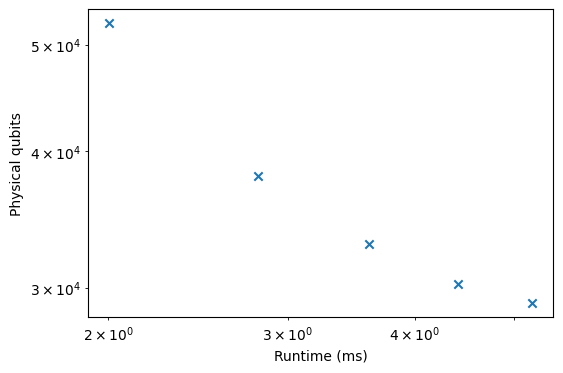

In [10]:
# Log-log Pareto frontier: runtime (x) vs physical qubits (y)
plot_estimates(results, figsize=(6, 4), runtime_unit="ms")

The plot visualizes the Pareto frontier: each point represents a configuration that is optimal in the sense that no other configuration achieves both fewer qubits *and* a shorter runtime. Moving left along the x-axis trades qubits for speed, while moving down trades speed for fewer qubits.

## Compare multiple estimations

A common workflow is to compare resource estimates across different hardware assumptions. Here we sweep over three physical error rates and run a separate estimation for each. The `name` parameter labels each run so the results can be distinguished in the plot. Passing the list of `EstimationTable` objects to `plot_estimates` overlays them on a single figure with a legend.

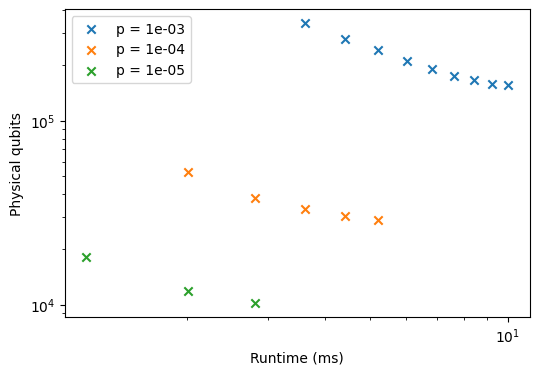

In [11]:
# Compare estimates across different physical error rates
results = []

for error_rate in [1e-3, 1e-4, 1e-5]:
    arch = GateBased(error_rate=error_rate, gate_time=100, measurement_time=500)
    results.append(estimate(app, arch, isa_query=SurfaceCode.q() * RoundBasedFactory.q(), max_error=0.01, name=f"p = {error_rate:.0e}"))

# Overlay multiple estimation runs on a single plot
plot_estimates(results, figsize=(6, 4), runtime_unit="ms")

## Next steps

This notebook covered the basic workflow for quantum resource estimation. To explore further:

- Try different Q# applications from the `samples/` directory
- Adjust the architecture parameters (e.g., different `error_rate` or `gate_time` values) to see how hardware assumptions affect the estimates
- Explore different ISA queries, such as varying the surface code distance range with `SurfaceCode.q(distance=range(3, 30, 2))`
- Compare results across multiple estimation runs using `plot_estimates`

To learn how to estimate quantum programs written in various languages and frameworks, check out the [Importing quantum programs into QRE](1_qre_input.ipynb) notebook.